# Water Distribution System Design and Operations Optimisation

This notebook illustrates how to approach Water Distribution System (WDS) optimisation problems dealing with design and operations considerations simultaneously.
We show the main challenges on a simplified formulation of the Anytown problem.

**Network:** Anytown benchmark network (1 reservoir, 2 tanks, xx junctions, yy pipes)

**Tools:** [EPyT](https://github.com/OpenWaterAnalytics/EPyT) (EPANET Python Toolkit) · [PyGMO](https://esa.github.io/pygmo2/) (optimisation)

## Notebook setup

Run the first two cells once to set up all the tools and libraries necessary to run this notebook.

In [ ]:
# Install conda on Colab (workaround to have its specific build tools on Colab)
!python --version
!pip install condacolab
import condacolab
condacolab.install()

Python 3.11.13
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


: 

In [1]:
# Install PyGMO using conda (workaround to have PyGMO on Colab)
!python --version
!conda install pygmo
!pip install epyt

Python 3.11.11
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - pygmo


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ampl-asl-1.0.0             |       h5888daf_2         504 KB  conda-forge
    asttokens-3.0.1            |     pyhd8ed1ab_0          28 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    certifi-2026.4.22          |     pyhd8ed1ab_0         132 KB  conda-forge
    cloudpickle-3.1.2          |     pyhcf101f3_1          27 KB  conda-forge
    comm-0.2.3                 |     pyhe01879c_0          14 KB  conda-forge
    conda-26.3.2               |  py311h38be061_1         1.2 MB  conda-forge
    conda-libmamba-solver-26.4.1|     pyhd8ed1ab_0 

In [2]:
# Import the necessary components
from epyt import epanet
import pygmo
import numpy as np
from typing import Tuple
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm

## The Anytown problem



EPANET version 20305 loaded (EPyT version v2.3.5.0 - Last Update: 20/02/2026).
Publication DOI: https://zenodo.org/records/18484878
Input File anytown-exeter.inp loaded successfully.



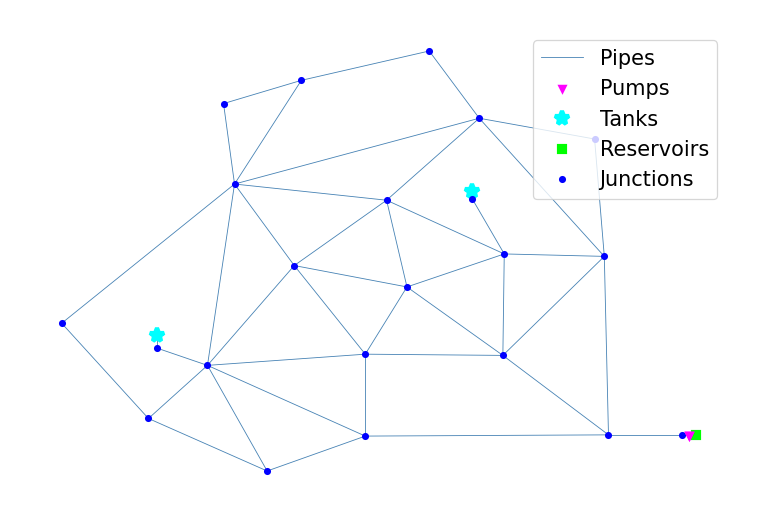

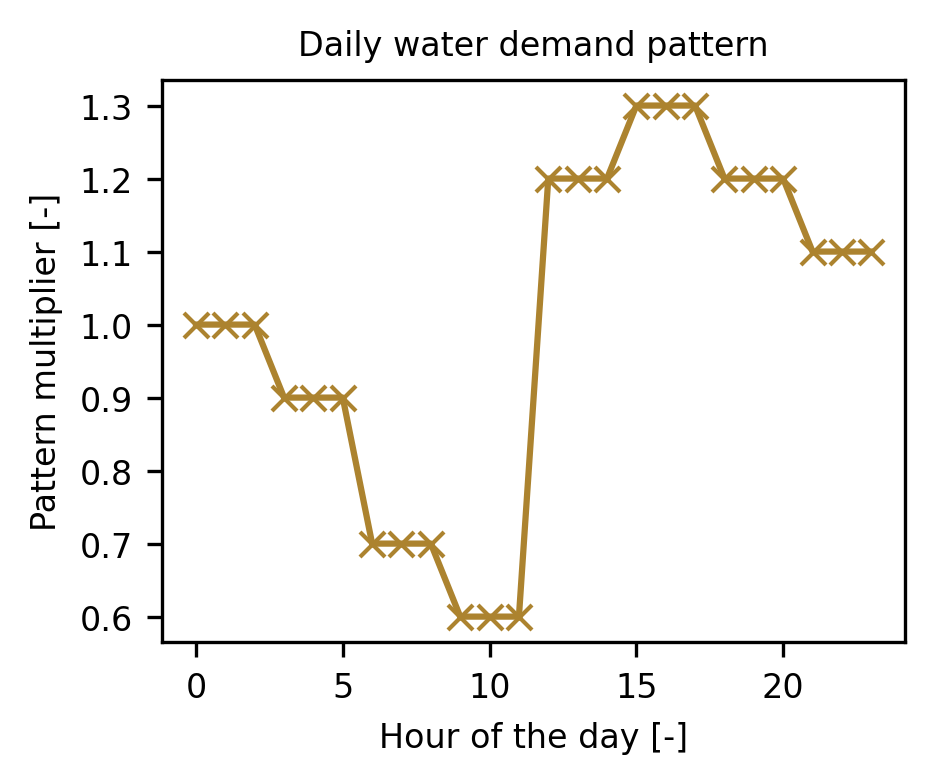

In [4]:
anytown_network = epanet('anytown-exeter.inp')
anytown_network.plot();

demand_pattern = anytown_network.getPattern()[0]
anytown_network.plot_ts(
    X=range(24),
    Y=demand_pattern,
    title="Daily water demand pattern",
    xlabel="Hour of the day [-]",
    ylabel="Pattern multiplier [-]"
  )

## Define the Anytown Problem



In [ ]:
class AnytownDesignProblem:

  AVAILABLE_DIAMETERS = np.array([6, 8, 10, 12, 14, 16, 18, 20, 24, 30]) # inches

  # We encode the decision for the diameter option of a single pipe as an integer indicating the
  # index in the list of available diameters
  SMALLEST_DIAM_OPTION = 0
  BIGGEST_DIAM_OPTION = len(AVAILABLE_DIAMETERS)-1
  DO_NOTHING_OPTION = -1

  NEW_PIPE_RGH_C = 120

  NEW_PIPES_ID = ["110", "113", "114", "115", "116", "125"]

  # We exclude these two short pipes (1 ft) that are in the model mainly
  # for visualization purposes
  EXC_PIPES_ID = ["142", "143"]

  PUMPS_ID = ["78", "79", "80"]
  PUMPS_PATTERNS_ID = ["2", "3", "4"]

  TARGET_PRESSURE = 40 # psi
  MIN_PRESSURE = 20 # psi

  # Nodes on which to check minimum pressure
  DEMAND_NODES_ID = [
    "1", "2", "3", "4", "5" , "6", "7", "8", "9", "10",
    "11", "12", "13", "14", "15", "16", "17", "18", "19",
  ]

  N_OBJECTIVES = 2
  N_INEQUALITY_CONSTRAINTS = 0
  N_EQUALITY_CONSTRAINTS = 0

  def __init__(self, pumping_station_pattern: list[int]) -> None:
    """
    We initialise a problem instance based on the information included in the network.
    The same network must be then be accessible in the fitness function.
    We don't store it in the class because the problem object needs to be serializable
    (pickable), unfortunately, EPyT objects are not and even if they were, they
    would be very expensive to copy and serialize every time.
    """
    self._init_network()
    self._init_EN_helpers()
    self._init_bounds()
    self._apply_pstat_pattern(
        pattern=np.array(pumping_station_pattern)
    )
    self._init_fitness_bounds()

  def get_bounds(self) -> Tuple[np.ndarray, np.ndarray]:
    return self.lb, self.ub

  def get_nix(self) -> int:
    return len(self.lb)

  def get_nobj(self) -> int:
    return self.N_OBJECTIVES

  def get_nic(self) -> int:
    return self.N_INEQUALITY_CONSTRAINTS

  def get_nec(self) -> int:
    return self.N_EQUALITY_CONSTRAINTS

  def fitness(self, x: np.ndarray) -> np.ndarray:
    self._apply_dvs(x)
    fv = self._compute_fitness(x)
    self._reset_dvs(x)
    return fv

  def _init_network(self) -> None:
    """
    Override the default configurations of the EPANET Anytown network
    """
    anytown_network.setTimeHydraulicStep(60*15) # 15 minute time step
    anytown_network.setDemandModel('PDA', self.MIN_PRESSURE, self.TARGET_PRESSURE, 0.5)

  def _init_EN_helpers(self) -> None:
    """
    Since we never change the network topology, we can cache a few helpful
    information about the elements in the EPANET network.
    """

    # Let's get which pipes can be rehabilitated: all those that are not new or excluded on purpose
    self.REH_PIPES_ID = [
        link_id
        for link_id, link_type in zip(
            anytown_network.getLinkNameID(),
            anytown_network.getLinkType()
        )
        if (
            link_type == 'PIPE' and
            link_id not in self.NEW_PIPES_ID and
            link_id not in self.EXC_PIPES_ID
        )
    ]

    # Let's cache the EPANET indexes of the pipe on which we will work on
    self.NEW_PIPES_ENIDX = [
        anytown_network.getLinkIndex(p)
        for p in self.NEW_PIPES_ID
    ]
    self.REH_PIPES_ENIDX = [
        anytown_network.getLinkIndex(p)
        for p in self.REH_PIPES_ID
    ]

    # Let's cache the original pipes' diameter and roughness that we will rehabilitate
    # we need this because once we install a new pipe there, we will change its
    # diameter and roughness in place.
    self.REH_PIPES_ORIG_DIAM = anytown_network.getLinkDiameter(self.REH_PIPES_ENIDX)
    self.REH_PIPES_ORIG_RGH_C = anytown_network.getLinkRoughnessCoeff(self.REH_PIPES_ENIDX)

    # As we did for the pipes, we store the EPANET index of the pump patterns
    # so that we can change their controls if necessary
    self.PUMPS_PATTERNS_ENIDX = anytown_network.getPatternIndex(self.PUMPS_PATTERNS_ID)

    # Once again, we extract the pumps index (index in the list of links) to extract
    # the results. However, we are going to extract them from a 2d np.array so we need
    # the Python indexes (starts from 0) alongside the EPANET index (starts from 1)
    self.PUMPS_ENIDX = [
        anytown_network.getLinkIndex(p)
        for p in self.PUMPS_ID
    ]
    self.PUMPS_IDX = [i-1 for i in self.PUMPS_ENIDX]

    # Same thing for the demand nodes, let's cache the EPANET and Python index
    # of the demand nodes on which we need to check the minimum pressure
    self.DEMAND_NODES_ENIDX = [
        anytown_network.getNodeIndex(n)
        for n in self.DEMAND_NODES_ID
    ]
    self.DEMAND_NODES_IDX = [i-1 for i in self.DEMAND_NODES_ENIDX]

  def _init_bounds(self) -> None:
    # New pipes must be installed. Thus, each pipe decision variable is an integer
    # representing the index in the list of available diameters.
    lb_new_pipe = self.SMALLEST_DIAM_OPTION
    ub_new_pipe = self.BIGGEST_DIAM_OPTION
    n_new_pipes = len(self.NEW_PIPES_ID)

    # Other pipes that can be rehabilitate can be ignored (do-nothing option)
    # or replaced with a new diameter. Same approach as the new pipes (index of the list)
    # but with the do-nothing option as lower bound.
    lb_reh_pipe = self.DO_NOTHING_OPTION
    ub_reh_pipe = self.BIGGEST_DIAM_OPTION
    n_reh_pipes = len(self.REH_PIPES_ID)

    # Finally let's compose the decision variable bounds. We prefer to put new pipes first.
    self.lb = np.array(
      [lb_new_pipe]*n_new_pipes + [lb_reh_pipe]*n_reh_pipes
    )
    self.ub = np.array(
      [ub_new_pipe]*n_new_pipes + [ub_reh_pipe]*n_reh_pipes
    )

  def _init_fitness_bounds(self) -> None:
    """
    Calculate and store the minimum and maximum value that some objectives can take.

    1.
    We can compute the minium and the maximum of the total network volume installed
    as the minimum takes place when we install the lowest decision variable value for both the
    new pipes and the pipes to replace.

    2.
    I don't know a way to compute the bounds of the energy function.

    3.
    The smallest undelivered demand is of course zero, the biggest is all of it.
    """
    total_net_vol = 0.0
    # Compute the new pipes' subnetwork volume (must be installed, hence smallest diam option)
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.NEW_PIPES_ID),), fill_value=self.SMALLEST_DIAM_OPTION),
        self.NEW_PIPES_ENIDX
    )
    # Compute the rehabilitation pipes' subnetwork volume (can avoid install, hence do noting option)
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.REH_PIPES_ID),), fill_value=self.DO_NOTHING_OPTION),
        self.REH_PIPES_ENIDX
    )
    self.TOTAL_NETWORK_VOLUME__MIN = total_net_vol

    # Same calculation but for the biggest possible alternative
    total_net_vol = 0.0
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.NEW_PIPES_ID),), fill_value=self.BIGGEST_DIAM_OPTION),
        self.NEW_PIPES_ENIDX
    )
    total_net_vol += self._compute_subnetwork_volume(
        np.full(shape=(len(self.REH_PIPES_ID),), fill_value=self.BIGGEST_DIAM_OPTION),
        self.REH_PIPES_ENIDX
    )
    self.TOTAL_NETWORK_VOLUME__MAX = total_net_vol


    self.UNDELIVERED_DEMAND__MIN = 0.0
    self.UNDELIVERED_DEMAND__MAX = sum(anytown_network.getNodeBaseDemands()[1])*60*24 # Gallons per day

  def _apply_dvs(self, x: np.ndarray) -> None:
    """
    Apply the decision variables vector x to the problem and the anytown_network object
    """
    # As set up in the init bounds function, first we put the decision variables
    # of the n new pipes, then we leave the decision variables of the rehab pipes.
    n_new_pipes = len(self.NEW_PIPES_ID)
    n_reh_pipes = len(self.N_REH)
    new_pipes_dvs = x[0:n_new_pipes].astype(int)
    reh_pipes_dvs = x[n_new_pipes:].astype(int)

    self._apply_pipe_dvs(new_pipes_dvs, self.NEW_PIPES_ENIDX)
    self._apply_pipe_dvs(reh_pipes_dvs, self.REH_PIPES_ENIDX)

  def _reset_dvs(self, x: np.ndarray) -> None:
    """
    Reset the problem and the anytown network object to thier original values
    before applying the x solution
    """
    # No need to reset the new pipes as we overwrite them at every evaluation of a solution
    # While we must do it for the rehabilitated pipes
    self._reset_pipe_dvs(
        self.REH_PIPES_ENIDX,
        self.REH_PIPES_ORIG_DIAM,
        self.REH_PIPES_ORIG_RGH_C
    )

  def _apply_pipe_dvs(self, pipes_dvs: np.ndarray, pipes_ENidx: list[int]) -> None:
    """
    Apply the pipe diameter option for a list of pipes
    """
    for pipe_ENidx, pipe_dv in zip(pipes_ENidx, pipes_dvs):
      if pipe_dv == self.DO_NOTHING_OPTION:
        continue

      diameter_option = self.AVAILABLE_DIAMETERS[pipe_dv]

      anytown_network.setLinkDiameter(pipe_ENidx, diameter_option)
      anytown_network.setLinkRoughnessCoeff(pipe_ENidx, self.NEW_PIPE_RGH_C)

  def _reset_pipe_dvs(
      self,
      pipes_ENidx: list[int],
      pipes_orig_diams: list[float],
      pipes_orig_rgh_c: list[float]
  ) -> None:
    """
    Reset the pipe diameter and roughness of a pipe to its original values
    """
    anytown_network.setLinkDiameter(pipes_ENidx, pipes_orig_diams)
    anytown_network.setLinkRoughnessCoeff(pipes_ENidx, pipes_orig_rgh_c)
    return

  def _apply_pstat_pattern(self, pattern: np.ndarray) -> None:
    assert len(pattern) == 24 and all(pattern >= 0 ) and all(pattern <= len(self.PUMPS_PATTERNS_ID)), \
      "We expect a pumping pattern with 24 values (one per hour of the day) and containing the number of pumps running at that hour"

    for i, pump_pattern_ENidx in enumerate(self.PUMPS_PATTERNS_ENIDX):
      pump_pattern = (pattern > i).astype(float)

      anytown_network.setPattern(pump_pattern_ENidx, pump_pattern)

    return

  def _compute_fitness(self, x: np.ndarray) -> np.ndarray:

    # First objective: total network volume replaced
    total_net_vol = 0.0
    # As set up in the init bounds function, first we put the decision variables
    # of the n new pipes, then we leave the decision variables of the rehab pipes.
    n_new_pipes = len(self.NEW_PIPES_ID)
    new_pipes_dvs = x[0:n_new_pipes].astype(int)
    reh_pipes_dvs = x[n_new_pipes:].astype(int)

    total_net_vol += self._compute_subnetwork_volume(
        new_pipes_dvs,
        self.NEW_PIPES_ENIDX
    )
    total_net_vol += self._compute_subnetwork_volume(
        reh_pipes_dvs,
        self.REH_PIPES_ENIDX
    )

    # Second objective: total energy consumption (needs simulation)
    hyd_results = anytown_network.getComputedHydraulicTimeSeries()

    total_energy = np.sum(hyd_results.Energy[:, self.PUMPS_IDX])

    # Third objective: undelivered demand (we normalise it)
    udemands = (
        hyd_results.DemandRequested[:, self.DEMAND_NODES_IDX] -
        hyd_results.DemandDelivered[:, self.DEMAND_NODES_IDX]
    )
    total_udemands = np.sum(udemands)*60 # Gallons per day
    normalised_demands = (total_udemands - self.UNDELIVERED_DEMAND__MIN)/(
        self.UNDELIVERED_DEMAND__MAX - self.UNDELIVERED_DEMAND__MIN
    )
    # let's round it so that we don't get too many points with similar undelivered
    # demands as we don't care about those solutions.
    normalised_demands = np.round(normalised_demands, 1)

    if total_udemands > 0:
      return np.array([
          total_net_vol,
          normalised_demands
      ])

    return np.array([
        total_net_vol,
        -1/total_energy
      ])

  def _compute_subnetwork_volume(self, pipes_dvs: np.ndarray, pipes_ENidx: list[int]) -> float:
    """
    Return the total network volume replaced by the decision vector on the list of pipes
    """
    total_volume = 0.0
    for pipe_ENidx, pipe_dv in zip(pipes_ENidx, pipes_dvs):
      if pipe_dv == self.DO_NOTHING_OPTION:
        continue

      pipe_diam = self.AVAILABLE_DIAMETERS[pipe_dv] / 12 # feet
      pipe_length = anytown_network.getLinkDiameter(pipe_ENidx)

      total_volume += 3.14 * pipe_diam * pipe_diam /4 * pipe_length

    return total_volume



## Run the Optimisation (1)

### Decide the Operations

[1.         1.         1.         0.89999998 0.89999998 0.89999998
 0.69999999 0.69999999 0.69999999 0.60000002 0.60000002 0.60000002
 1.20000005 1.20000005 1.20000005 1.29999995 1.29999995 1.29999995
 1.20000005 1.20000005 1.20000005 1.10000002 1.10000002 1.10000002]


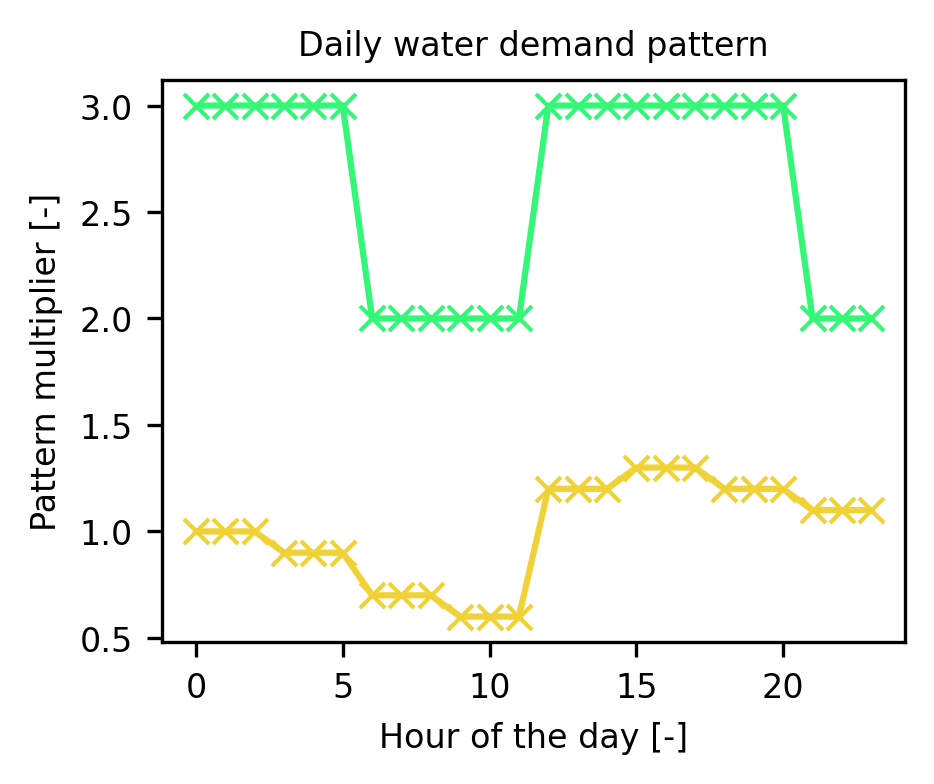

In [8]:
PUMPING_STATION_SCHEDULE = [3]*6+[2]*6+[3]*9+[2]*3

demand_pattern = anytown_network.getPattern()[0]
print(demand_pattern)
anytown_network.plot_ts(
    X=range(24),
    Y=np.vstack([demand_pattern, PUMPING_STATION_SCHEDULE]).T,
    title="Daily water demand pattern",
    xlabel="Hour of the day [-]",
    ylabel="Pattern multiplier [-]"
  )

In [10]:
import warnings
# Ignore UserWarning from epyt about "may be hydraulically unstable" (It means it converged but it took more trials than allowed)
warnings.filterwarnings("ignore", message="WARNING: System may be hydraulically unstable.", module="epyt.src.epanetapi")

pg_prob = pygmo.problem(AnytownDesignProblem(
    pumping_station_pattern=PUMPING_STATION_SCHEDULE
  ))
pg_algo = pygmo.algorithm(pygmo.nsga2(gen=50))
pg_pop = pygmo.population(pg_prob, size=100)

In [11]:
pg_pop_final = pg_algo.evolve(pg_pop)
print(pg_pop_final)

/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())
/usr/local/lib/python3.11/site-packages/epyt/src/epanetapi.py:1116: UserWarning: WARNING: System hydraulically unbalanced.
  warnings.warn(errmssg.value.decode())


Problem name: <class '__main__.AnytownDesignProblem'>
	C++ class name: pybind11::object

	Global dimension:			41
	Integer dimension:			41
	Fitness dimension:			2
	Number of objectives:			2
	Equality constraints dimension:		0
	Inequality constraints dimension:	0
	Lower bounds: [0, 0, 0, 0, 0, ... ]
	Upper bounds: [9, 9, 9, 9, 9, ... ]
	Has batch fitness evaluation: false

	Has gradient: false
	User implemented gradient sparsity: false
	Has hessians: false
	User implemented hessians sparsity: false

	Fitness evaluations: 5100

	Thread safety: none

Population size: 100

List of individuals: 
#0:
	ID:			17775845833880692844
	Decision vector:	[3, 3, 0, 6, 6, ... ]
	Fitness vector:		[730.791, -1.25779e-05]
#1:
	ID:			7601148673602368575
	Decision vector:	[3, 3, 0, 3, 2, ... ]
	Fitness vector:		[539.688, -1.25694e-05]
#2:
	ID:			5537993260179699158
	Decision vector:	[3, 3, 0, 6, 6, ... ]
	Fitness vector:		[730.791, -1.25779e-05]
#3:
	ID:			17996917501555652070
	Decision vector:	[3, 3, 0, 2, 

## Update the PyGMO UDP to also Modify Controls

In [ ]:
class AnytownDesignOperProblem(AnytownOperDesignProblem):
    """
    The problem is effectively like the Design only problem, except for the fact that we don't
     fix the pumping station's schedule a-priori because it is optimised by the algorithm.

    Therefore, we ovverride only the functions that change and add new attributes.
    """
    MIN_N_RUNNING_PUMPS = 1
    MAX_N_RUNNING_PUMPS = 3

    def __init__(self) -> None:
        """
        We initialise a problem instance based on the information included in the network.
        The same network must be then be accessible in the fitness function.
        We don't store it in the class because the problem object needs to be serializable
        (pickable), unfortunately, EPyT objects are not and even if they were, they
        would be very expensive to copy and serialize every time.
        """
        self._init_network()
        self._init_EN_helpers()
        self._init_bounds()
        self._init_fitness_bounds()

    def _init_bounds(self) -> None:
        """
        
        """
        # The design only problem already has a method to init the bounds of the pipes decision
        # variables, so we will use that and extend it with pumps bounds 
        super()._init_bounds()
        
        lb_pstation = self.MIN_N_RUNNING_PUMPS
        ub_pstation = self.MAX_N_RUNNING_PUMPS
        n_pstation_dvs = 24 # Pumping station's schedule has an hourly timestamp

        self.lb = np.concatenate(
            self.lb,
            np.array([lb_pstation]*n_pstation_dvs)
        )
        self.ub = np.concatenate(
            self.ub,
            np.array([ub_pstation]*n_pstation_dvs)
        )
        
    def _apply_dvs(self, x: np.ndarray) -> None:

        # As the design and operations problems decision variable string, extends 
    

## Run the Optimisation (2)

## Compare the Results

## Beyond the Surface

More challenges and considerations for a real-world setup

